Available pollutant columns: ['CO', 'NO2', 'PM25', 'PM10', 'O3', 'building', 'sky', 'vegetation', 'road']
Available morphology columns: []
Saved autocorrelation results to: ./lag_autocorrelation\lag_autocorrelation_results.csv


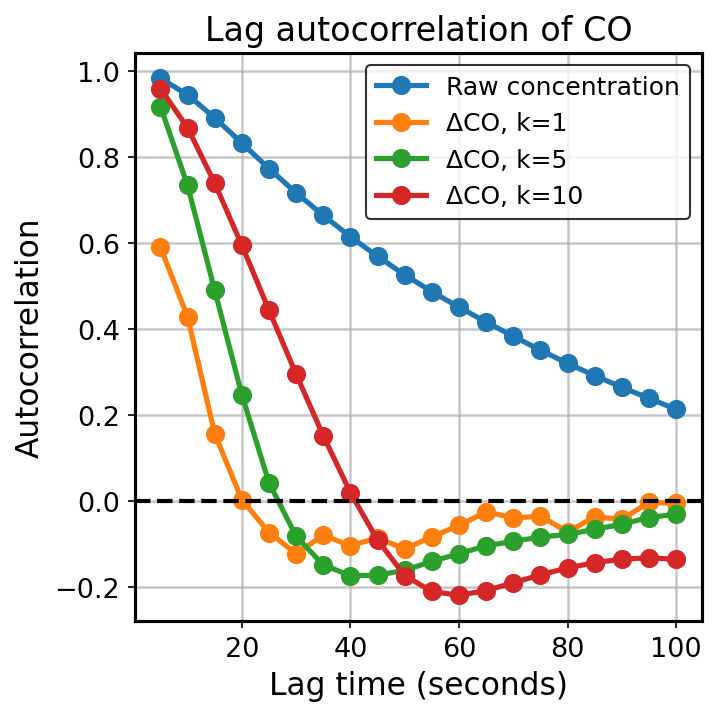

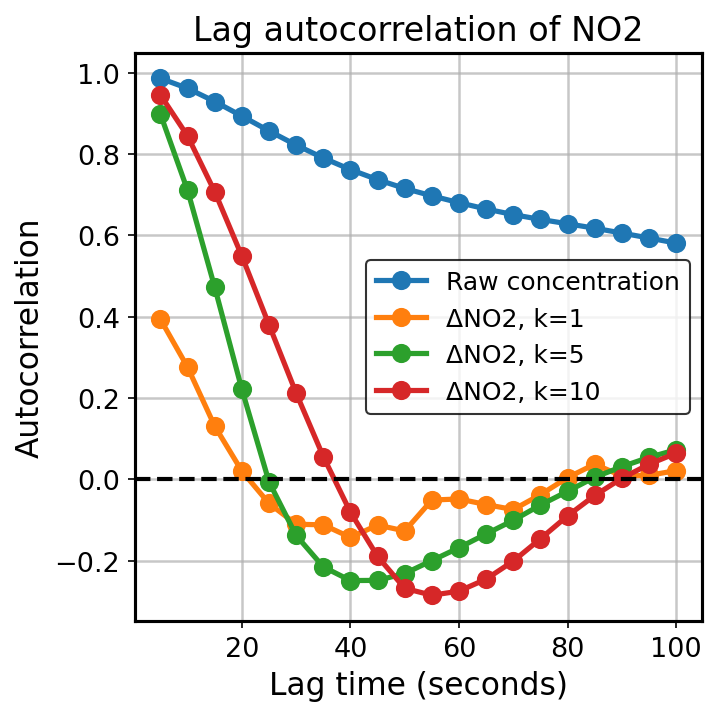

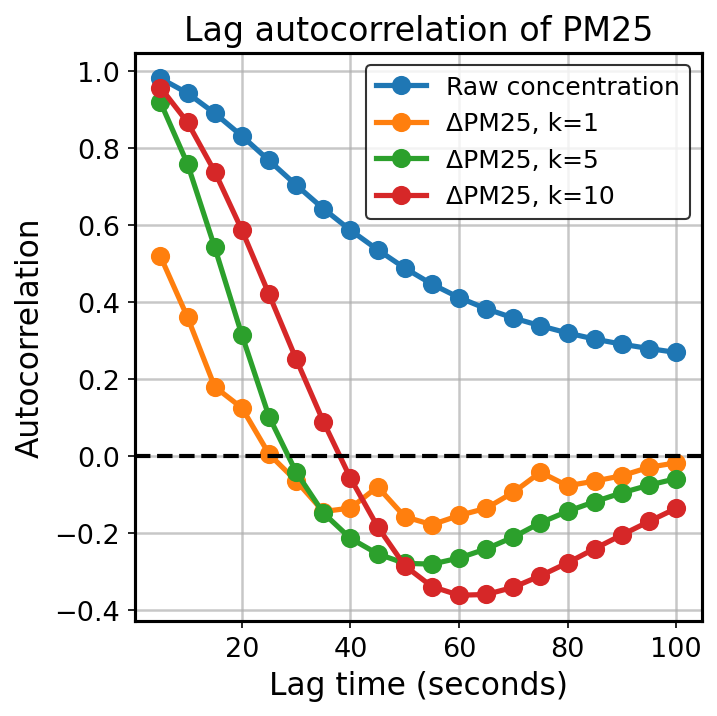

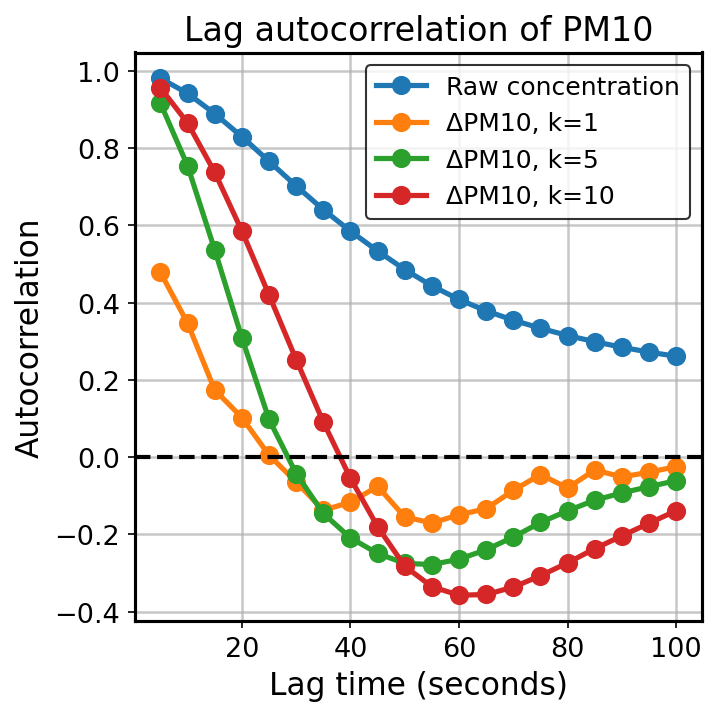

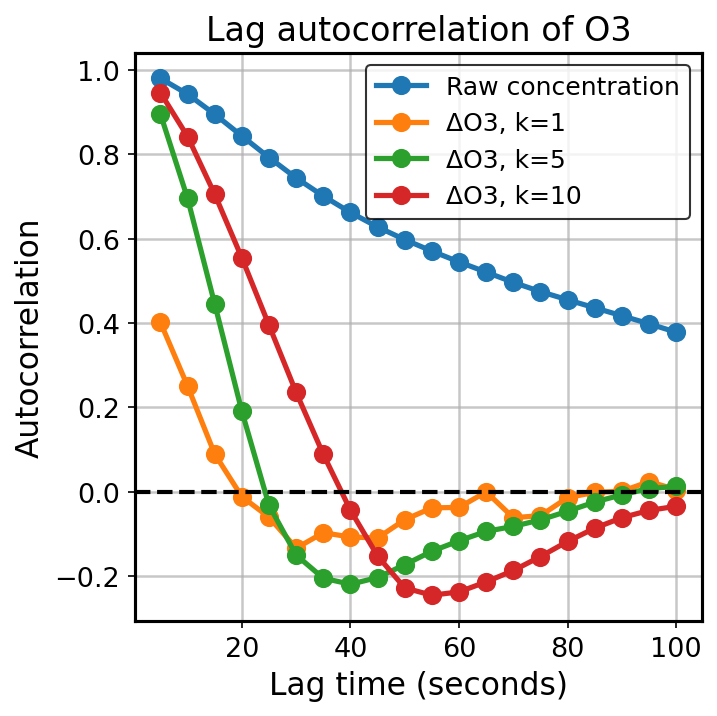

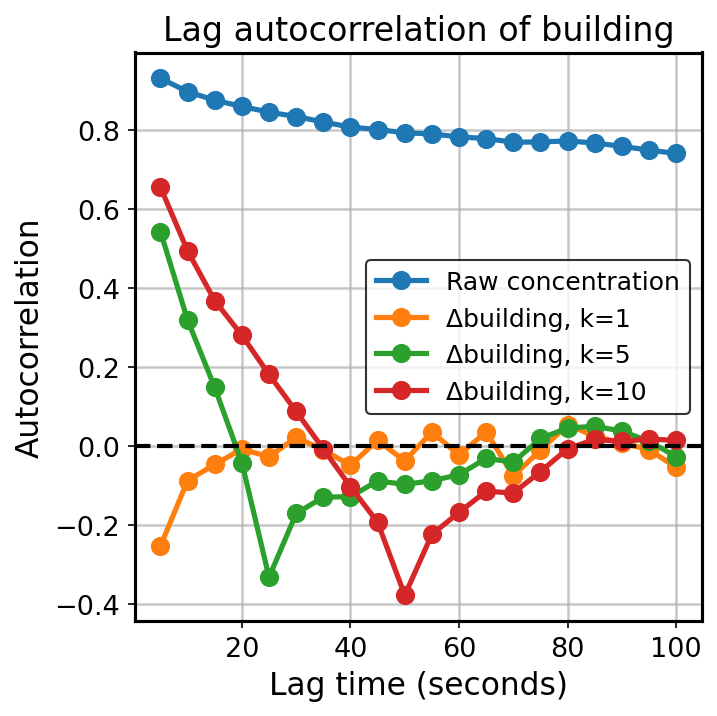

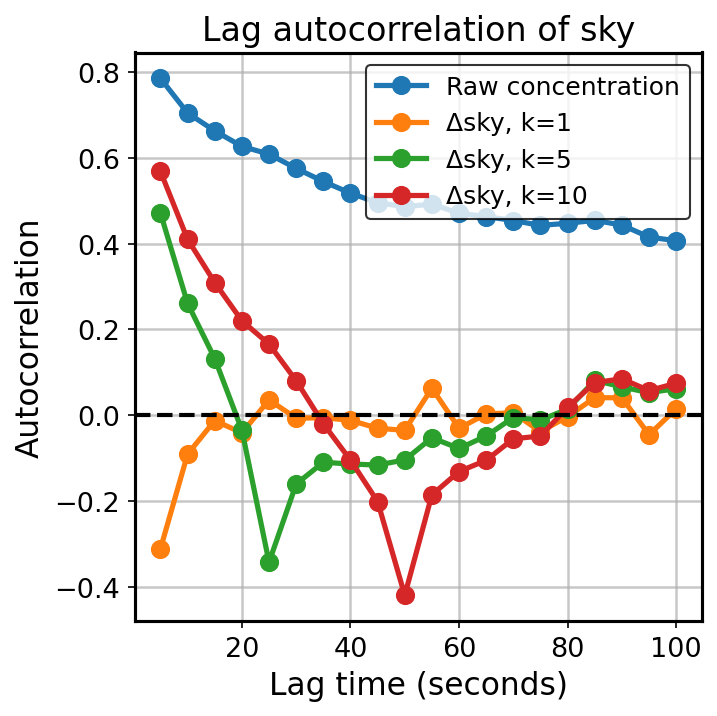

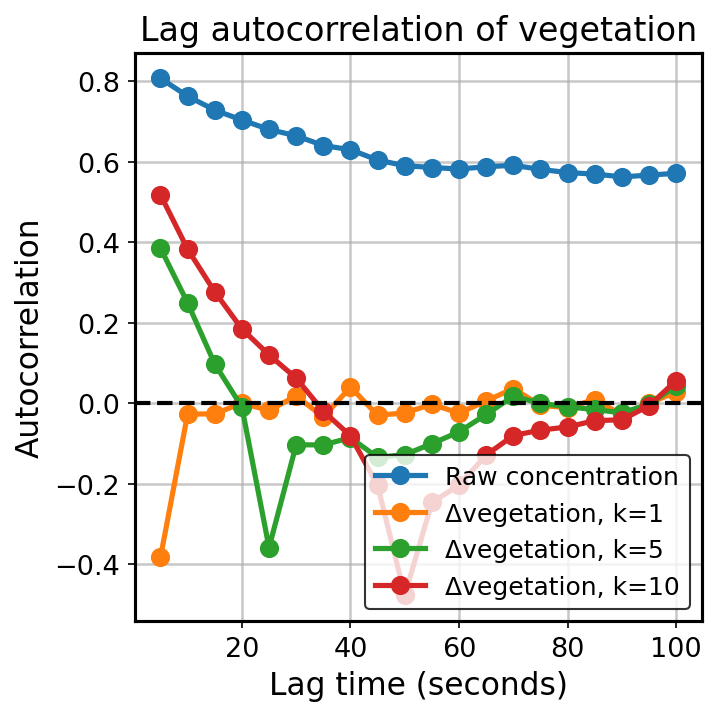

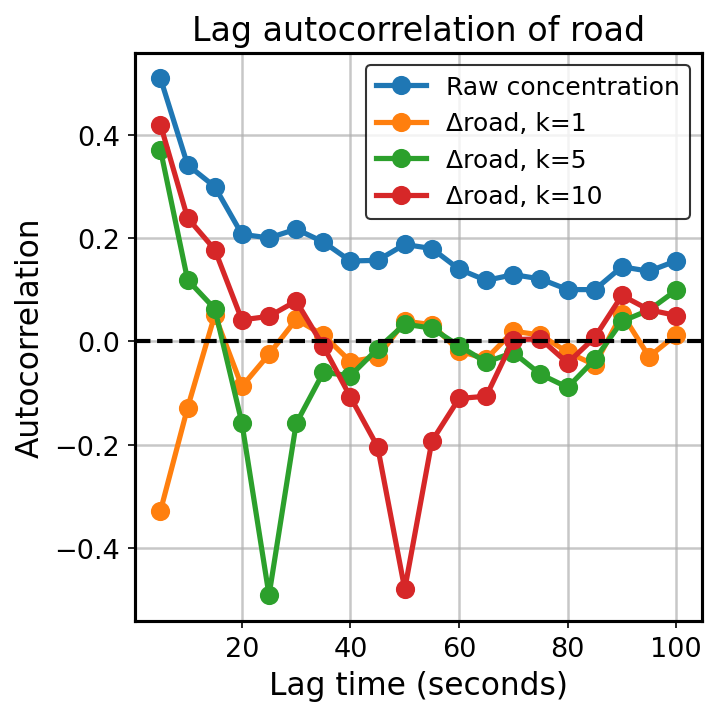


===== Summary =====
      variable          data_type  lag1_autocorr  lag5_autocorr  \
0           CO           delta_k1         0.5900        -0.0725   
1           CO          delta_k10         0.9588         0.4438   
2           CO           delta_k5         0.9170         0.0427   
3           CO  raw_concentration         0.9824         0.7729   
4          NO2           delta_k1         0.3933        -0.0595   
5          NO2          delta_k10         0.9452         0.3798   
6          NO2           delta_k5         0.8978        -0.0065   
7          NO2  raw_concentration         0.9862         0.8569   
8           O3           delta_k1         0.4014        -0.0599   
9           O3          delta_k10         0.9452         0.3945   
10          O3           delta_k5         0.8946        -0.0320   
11          O3  raw_concentration         0.9793         0.7918   
12        PM10           delta_k1         0.4780         0.0049   
13        PM10          delta_k10        

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================== Global Matplotlib Style Settings (Enlarge fonts & thicken lines) =====================
plt.rcParams.update({
    # Global font size scaling
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    # Thicken plot lines
    "lines.linewidth": 2.5,
    "lines.markersize": 8,
    "lines.markeredgewidth": 1.2,
    # Thicken axes and grid lines
    "axes.linewidth": 1.5,
    "grid.linewidth": 1.2,
    # Legend border configuration
    "legend.frameon": True,
    "legend.edgecolor": "black",
    # High resolution output
    "figure.dpi": 150,
})

# ===================== User Custom Parameters =====================
input_csv = "20260323_Matched.csv"     # Single daily raw trajectory dataset
output_dir = "./lag_autocorrelation"
os.makedirs(output_dir, exist_ok=True)

sampling_interval_seconds = 5          # Mobile sensor sampling interval (seconds)
max_lag = 20                           # 20 lags = 100 seconds under 5s sampling interval
delta_k_list = [1, 5, 10]              # Compute ΔC with lag k = 1, 5, 10

pollutant_cols = ["CO", "NO2", "PM25", "PM10", "O3", "building", "sky", "vegetation", "road"]

morphology_cols = [
    # "building", "sky", "vegetation", "road",
]

# Specify timestamp column if available; set to None if absent
time_col = None
# Example assignment:
# time_col = "timestamp"
# ==================================================================================


def clean_numeric_series(s):
    """Convert input to numeric series and remove NaN / infinite values."""
    s = pd.to_numeric(s, errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    return s.reset_index(drop=True)


def lag_autocorrelation(series, max_lag):
    """Calculate autocorrelation coefficients from lag 1 to specified max lag."""
    series = clean_numeric_series(series)
    results = []

    for lag in range(1, max_lag + 1):
        if len(series) <= lag + 2:
            acf = np.nan
        else:
            acf = series.autocorr(lag=lag)

        results.append({
            "lag": lag,
            "lag_seconds": lag * sampling_interval_seconds,
            "autocorrelation": acf
        })

    return pd.DataFrame(results)


def compute_delta(series, k):
    """Calculate differential value ΔC = C(t+k) - C(t)."""
    series = clean_numeric_series(series)
    if len(series) <= k:
        return pd.Series(dtype=float)
    delta = series.shift(-k) - series
    return delta.dropna().reset_index(drop=True)


# ===================== Load Input Dataset =====================
df = pd.read_csv(input_csv)

if time_col is not None and time_col in df.columns:
    df = df.sort_values(time_col).reset_index(drop=True)

available_pollutants = [c for c in pollutant_cols if c in df.columns]
available_morphology = [c for c in morphology_cols if c in df.columns]

print("Available pollutant columns:", available_pollutants)
print("Available morphology feature columns:", available_morphology)

all_records = []

# ===================== Step 1: Autocorrelation for Raw Pollutant Concentrations =====================
for col in available_pollutants:
    acf_df = lag_autocorrelation(df[col], max_lag)
    acf_df["variable"] = col
    acf_df["data_type"] = "raw_concentration"
    all_records.append(acf_df)

# ===================== Step 2: Autocorrelation for Differential Pollutant Values =====================
for col in available_pollutants:
    for k in delta_k_list:
        delta_series = compute_delta(df[col], k=k)
        acf_df = lag_autocorrelation(delta_series, max_lag)
        acf_df["variable"] = col
        acf_df["data_type"] = f"delta_k{k}"
        all_records.append(acf_df)

# ===================== Step 3: Autocorrelation for Urban Morphology Features =====================
for col in available_morphology:
    acf_df = lag_autocorrelation(df[col], max_lag)
    acf_df["variable"] = col
    acf_df["data_type"] = "morphology_raw"
    all_records.append(acf_df)

# ===================== Export Full Autocorrelation Results =====================
result_df = pd.concat(all_records, axis=0, ignore_index=True)
result_csv = os.path.join(output_dir, "lag_autocorrelation_results.csv")
result_df.to_csv(result_csv, index=False, encoding="utf-8-sig")

print(f"Autocorrelation raw results saved to: {result_csv}")


# ===================== Plot 1: Raw vs Differential Pollutant Autocorrelation Curves =====================
for pollutant in available_pollutants:
    # Set canvas figure size
    plt.figure(figsize=(5, 5))

    sub_raw = result_df[
        (result_df["variable"] == pollutant) &
        (result_df["data_type"] == "raw_concentration")
    ]
    plt.plot(
        sub_raw["lag_seconds"],
        sub_raw["autocorrelation"],
        marker="o",
        label="Raw concentration"
    )

    for k in delta_k_list:
        sub_delta = result_df[
            (result_df["variable"] == pollutant) &
            (result_df["data_type"] == f"delta_k{k}")
        ]
        plt.plot(
            sub_delta["lag_seconds"],
            sub_delta["autocorrelation"],
            marker="o",
            label=f"Δ{pollutant}, k={k}"
        )

    # Thick dashed baseline at correlation = 0
    plt.axhline(0, linewidth=2, color="black", linestyle="--")
    plt.xlabel("Lag time (seconds)")
    plt.ylabel("Autocorrelation Coefficient")
    plt.title(f"Lag Autocorrelation of {pollutant}")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.tight_layout()

    fig_path = os.path.join(output_dir, f"acf_{pollutant}.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

# ===================== Plot 2: Morphology Feature Autocorrelation Curves =====================
if len(available_morphology) > 0:
    plt.figure(figsize=(5, 5))

    for col in available_morphology:
        sub = result_df[
            (result_df["variable"] == col) &
            (result_df["data_type"] == "morphology_raw")
        ]
        plt.plot(
            sub["lag_seconds"],
            sub["autocorrelation"],
            marker="o",
            label=col
        )

    plt.axhline(0, linewidth=2, color="black", linestyle="--")
    plt.xlabel("Lag time (seconds)")
    plt.ylabel("Autocorrelation Coefficient")
    plt.title("Lag Autocorrelation of Urban Morphology Features")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.tight_layout()

    fig_path = os.path.join(output_dir, "acf_morphology_features.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()


# ===================== Generate Statistical Summary Table =====================
summary = (
    result_df
    .groupby(["variable", "data_type"])
    .agg(
        lag1_autocorr=("autocorrelation", lambda x: x.iloc[0] if len(x) > 0 else np.nan),
        lag5_autocorr=("autocorrelation", lambda x: x.iloc[4] if len(x) > 4 else np.nan),
        lag10_autocorr=("autocorrelation", lambda x: x.iloc[9] if len(x) > 9 else np.nan),
        mean_autocorr=("autocorrelation", "mean")
    )
    .reset_index()
)

summary_csv = os.path.join(output_dir, "lag_autocorrelation_summary.csv")
summary.to_csv(summary_csv, index=False, encoding="utf-8-sig")

print("\n===== Autocorrelation Statistical Summary =====")
print(summary.round(4))
print(f"\nSummary table saved to: {summary_csv}")